# Praktikum Kecerdasan Artifisial Lanjut


---
## Bab 4. Pemrosesan Awal Data




Tuliskan Nama, NIM, dan kelas Anda:

Nama  : Hassan Nashrallah

NIM   : 245150200111025

Kelas : F



### 1) Import Data

Unduh dataset yang akan digunakan pada praktikum kali ini. Anda dapat menggunakan aplikasi **wget** untuk mendowload dataset dan menyimpannya dalam Google Colab. Jalankan cell di bawah ini untuk mengunduh **dataset sebagai latihan awal**. Untuk **tugas** gunakan **dataset yang tertera di modul praktikum (ada perbedaan *dataset*)**.

In [1]:
! wget https://dataset-kal.s3.us-east-1.amazonaws.com/iris_missing.csv

--2026-04-02 02:52:10--  https://dataset-kal.s3.us-east-1.amazonaws.com/iris_missing.csv
Resolving dataset-kal.s3.us-east-1.amazonaws.com (dataset-kal.s3.us-east-1.amazonaws.com)... 52.217.172.10, 16.15.191.20, 16.15.199.125, ...
Connecting to dataset-kal.s3.us-east-1.amazonaws.com (dataset-kal.s3.us-east-1.amazonaws.com)|52.217.172.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4593 (4.5K) [text/csv]
Saving to: ‘iris_missing.csv’

iris_missing.csv    100%[===================>]   4.49K  --.-KB/s    in 0s      

2026-04-02 02:52:10 (17.6 MB/s) - ‘iris_missing.csv’ saved [4593/4593]



Setelah dataset berhasil diunduh, langkah berikutnya adalah membaca dataset dengan memanfaatkan fungsi [readcsv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) dari library pandas. Lakukan pembacaan berkas csv menggunakan fungsi **readcsv**. Jangan lupa untuk melakukan import library pandas terlebih dahulu

In [2]:
import pandas as pd
import numpy as np
data = pd.read_csv('iris_missing.csv')

Tampilkan beberapa baris dari dataset untuk mendapatkan informasi singkat mengenai isi data. Gunakan fungsi **head()** untuk menampilkan 5 data pertama.

In [3]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,0.0,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Berdasarkan informasi dari fungsi **head()**, data iris yang
digunakan mempunyai 4 fitur sebagai berikut :


1.   sepal length
2.   sepal width
3.   petal length
4.   petal width

#### Penjelasan

Setelah dataset iris_missing diunduh, pembacaan file CSV dilakukan pada dataset tersebut dengan fungsi readcsv. Namun sebelum itu, dilakukan import library pandas dan numpy terlebih dahulu. Setelah file CSV tersebut dibaca dan disimpan dalam dataframe bernama data, lima baris teratas dari dataset tersebut akan ditampilkan dengan fungsi head(). Hal ini dilakukan untuk mendapatkan informasi singkat terkait isi dari dataset. Dari informasi yang ditampilkan oleh fungsi head(), dataset iris_missing memiliki empat fitur, yakni sepal length, sepal width, petal length, dan petal width. Selain itu, dataset tersebut juga menampilkan nama spesies iris dari setiap bunga iris yang diukur.

### 2) Cek Tipe Data dan Statistik Sederhana

Lakukan pengecekan dan pengubahan tipe data apabila tidak sesuai yang diharapkan

In [4]:
data['sepal_length'] = data['sepal_length'].astype(np.float32)

Coba panggil metode `describe()` dan `info()`. Jelaskan apa perbedaannya sebagai komentar.

In [5]:
data.info() 
#info() digunakan untuk melihat informasi umum tentang dataset.

data.describe() 
#describe() digunakan untuk melihat ringkasan statistik dari setiap kolom dalam dataset.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float32
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float32(1), float64(3), object(1)
memory usage: 5.4+ KB


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.731334,2.988000,3.684667,1.147333
std,1.153351,0.604893,1.826675,0.773790
min,0.000000,0.000000,0.000000,0.000000
25%,5.100000,2.800000,1.500000,0.225000
50%,5.800000,3.000000,4.300000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


#### Penjelasan

Pertama-tama, tipe data pada kolom sepal_length dicek agar sesuai dengan float32 `(astype(np.float32))`. Jika tidak sesuai, maka tipe data pada kolom tersebut akan diubah menjadi float32. Hal ini untuk memastikan kesesuaian tipe data pada dataset.

Kemudian, fungsi `info()` dan `describe()` dipanggil untuk melihat informasi terkait dataset. Kedua fungsi tersebut menampilkan output yang berbeda. Fungsi `info()` menampilkan informasi umum terkait dataset, seperti jumlah baris dan kolom, nama kolom, tipe data setiap kolom, jumlah nilai non-null untuk mengecek missing value, serta jumlah penggunaan memori. Sementara itu, fungsi `describe()` menampilkan ringkasan statistik dari setiap kolom dalam dataset, seperti jumlah data (count), rata-rata (mean), standar deviasi (std), nilai terkecil dan terbesar (min, max), serta nilai kuartil (25%, 50%, 75%).

### 3) Missing value dan imputasi data




Jika Anda perhatikan dengan seksama, data pada baris ke-3 (index 2) pada fitur sepal length memiliki nilai 0.0. Hal ini menandakan adanya missing value pada data. Jalankan cell di bawah ini untuk mendapatkan semua data yang mengandung missing value. Pencarian data yang mengandung missing value dilakukan dengan tahapan sebagai berikut:


1.   Membuat filter untuk mencari data dengan sepal_length = 0, sepal_width = 0, petal_length = 0, petal_width =0
2.   Mencari data yang memenuhi kondisi1 **atau** kondisi2 **atau** kondisi3 **atau** kondisi4 menggunakan property [loc](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.loc.html) pada dataframe



In [6]:
kondisi1 = data['sepal_length']==0.0
kondisi2 = data['sepal_width']==0.0
kondisi3 = data['petal_length']==0.0
kondisi4 = data['petal_width']==0.0
data.loc[kondisi1 | kondisi2 | kondisi3 | kondisi4]

,sepal_length,sepal_width,petal_length,petal_width,Species
2,0.0,3.2,1.3,0.2,Iris-setosa
11,0.0,3.4,1.6,0.2,Iris-setosa
32,5.2,0.0,1.5,0.1,Iris-setosa
47,4.6,3.2,0.0,0.2,Iris-setosa
51,6.4,0.0,4.5,1.5,Iris-versicolor
65,6.7,3.1,4.4,0.0,Iris-versicolor
67,5.8,2.7,0.0,1.0,Iris-versicolor
86,6.7,0.0,4.7,1.5,Iris-versicolor
107,0.0,2.9,6.3,1.8,Iris-virginica
112,6.8,3.0,0.0,2.1,Iris-virginica


Penanganan missing value pada Pandas akan lebih mudah apabila data yang hilang (bernilai 0.0) diganti dengan NaN (Not A Number). Gunakan properti **replace** pada dataframe untuk mengganti 0.0 menjadi NaN

In [7]:
data = data.replace(0.0, np.nan)

Terdapat beberapa cara untuk mengatasi permasalahan missing value pada data. Salah satu cara yang sederhana adalah dengan mengganti nilai NaN pada suatu fitur dengan rata-rata nilai fitur tersebut pada data lain yang bernilai bukan Nan. Perhatikan bahwa Anda harus mengganti nilai NaN dengan rata-rata data lain yang memiliki kategori (species) yang sama.

Fungsi-fungsi pada Pandas yang dapat Anda manfaatkan:


1.   **transform** untuk mengaplikasikan fungsi tertentu pada dataframe, pada permasalahan ini fungsi yang digunakan adalah fungsi **mean**
2.   **groupby** untuk mengelompokkan dataframe berdasarkan nilai kolom tertentu, pada permasalahan ini kolom yang digunakan adalah **species**
3. **fillna** untuk mengganti nilai NaN dengan nilai yang telah ditentukan




Buatlah fungsi bernama **imputasi** yang melakukan tahapan berikut:


1.   Menghitung rata-rata masing-masing kolom berdasarkan kelasnya
2.   Mengisi kolom yang berisi NaN dengan rata-rata kelas yang sesuai




In [8]:
def imputasi(df_input):
    list_column = df_input.columns
    class_column = list_column[-1]
    for column in list_column[:-1]:
        df_input[column] = df_input[column].fillna(
            df_input.groupby(class_column)[column].transform('mean'))
    return df_input

Buatlah sebuah dataframe baru bernama **data_imputasi** yang berisi dataset dengan nilai NaN yang sudah diganti dengan cara memanggil fungsi **imputasi**.

In [9]:
data_imputasi = imputasi(data)

Cek apakah masih terdapat nilai NaN pada dataframe.

In [ ]:
data_imputasi.isnull().values.any()
data_imputasi.isna().any()

,0
sepal_length,False
sepal_width,False
petal_length,False
petal_width,False
Species,False


#### Penjelasan

Pencarian missing value dapat dilakukan dengan membuat filter pada kondisi data = 0. Kemudian, dengan properti loc, data yang memenuhi kondisi pada filter tersebut dicari dan ditampilkan pada baris ke berapa missing value tersebut berada. Hasilnya terdapat 13 baris yang memiliki missing value atau data bernilai 0.0 pada salah satu kolomnya. 

Missing value perlu ditangani karena data bernilai 0.0 akan mempengaruhi hasil perhitungan statistik, seperti rata-rata atau standar deviasi. Salah satu penanganan missing value adalah dengan menggunakan fungsi replace() untuk mengganti data bernilai 0.0 dengan NaN (`data.replace(0.0, np.nan)`). Sehingga, data tersebut dapat dikenali sebagai missing value dan secara otomatis akan diabaikan oleh Pandas. 

Selain itu, penanganan missing value juga dapat dilakukan dengan mengganti nilai NaN dengan nilai tertentu berdasarkan nilai fitur lain yang bukan NaN. Teknik ini bernama imputasi data. Pada percobaan ini, imputasi data dilakukan dengan mencari nilai rata-rata dari setiap kelas, lalu nilai NaN diganti dengan nilai rata-rata dari kelas yang sesuai. Setelah dicek dengan fungsi isna() dan isnull(), data bernilai NaN dan 0.0 sudah tidak ada, dengan hasil false.

### 4) Pencarian Outlier
Lakukan plotting terhadap semua fitur pada dataset Iris. Hasil yang diharapkan seperti contoh berikut:

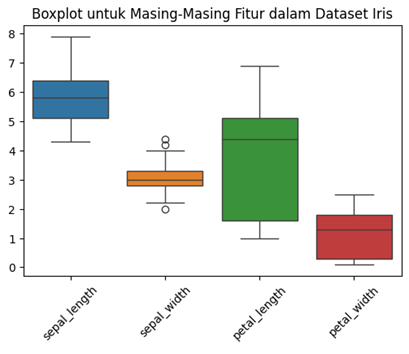

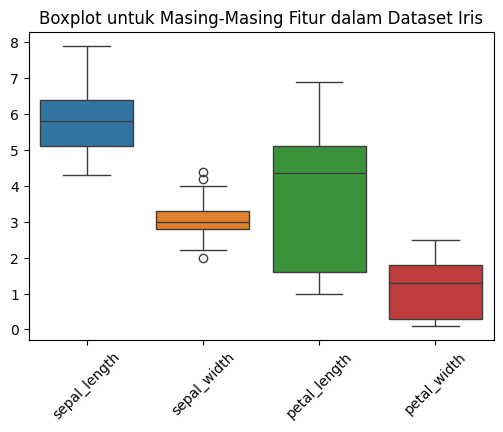

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.boxplot(data=data_imputasi)
plt.xticks(rotation=45)
plt.title('Boxplot untuk Masing-Masing Fitur dalam Dataset Iris')
plt.show()

Coba cari *outlier* dengan kode Python

Q1: 2.8, Q3: 3.3, IQR: 0.5
Lower Bound: 2.05, Upper Bound: 4.05
    sepal_length  sepal_width  petal_length  petal_width          Species
15           5.7          4.4           1.5          0.4      Iris-setosa
33           5.5          4.2           1.4          0.2      Iris-setosa
60           5.0          2.0           3.5          1.0  Iris-versicolor


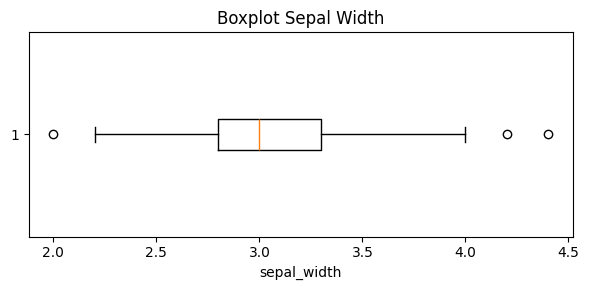

In [12]:
Q1 = data['sepal_width'].quantile(0.25)
Q3 = data['sepal_width'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['sepal_width'] < lower_bound) | (data['sepal_width'] > upper_bound)]
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
print(outliers)

plt.figure(figsize=(6, 3))
plt.boxplot(data['sepal_width'], vert=False)
plt.title('Boxplot Sepal Width')
plt.xlabel('sepal_width')
plt.tight_layout()
plt.show()

     sepal_length  sepal_width  petal_length  petal_width         Species
0        5.100000          3.5           1.4     0.200000     Iris-setosa
1        4.900000          3.0           1.4     0.200000     Iris-setosa
2        5.016667          3.2           1.3     0.200000     Iris-setosa
3        4.600000          3.1           1.5     0.200000     Iris-setosa
4        5.000000          3.6           1.4     0.200000     Iris-setosa
..            ...          ...           ...          ...             ...
145      6.700000          3.0           5.2     2.019149  Iris-virginica
146      6.300000          2.5           5.0     1.900000  Iris-virginica
147      6.500000          3.0           5.2     2.000000  Iris-virginica
148      6.200000          3.4           5.4     2.300000  Iris-virginica
149      5.900000          3.0           5.1     1.800000  Iris-virginica

[147 rows x 5 columns]


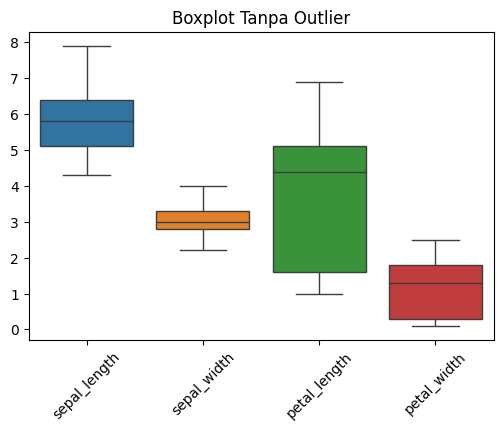

In [13]:
data_without_outliers = data[~((data['sepal_width'] < lower_bound) | (data['sepal_width'] > upper_bound))]
print(data_without_outliers)

plt.figure(figsize=(6, 4))
sns.boxplot(data=data_without_outliers)
plt.xticks(rotation=45)
plt.title('Boxplot Tanpa Outlier')
plt.show()

#### Penjelasan

Grafik BoxPlot dapat digunakan untuk memvisualisasikan outlier pada data. Dari grafik BoxPlot pertama, dapat dilihat bahwa ada tiga lingkaran yang berada di atas dan di bawah nilai ambang pada fitur sepal_width. Lingkaran tersebut bernilai 2.0, 4.4, dan 4.2, yang mana berada di luar nilai ambang bawah (2.05) dan ambang atas (4.05). Setelah data outlier ditemukan, kita dapat menghapus data outlier tersebut dengan menerapkan filter titik-titik data yang memenuhi syarat (`data[~((data['sepal_width'] < lower_bound) | (data['sepal_width'] > upper_bound))]`). Hasilnya, grafik BoxPlot kini bersih dari data outlier.

### 5) Normalisasi MinMax
Normalisasi bertujuan menyamakan rentang nilai pada setiap fitur. Beberapa metode pembelajaran mesin memiliki kinerja yang buruk apabila rentang nilai tiap variabel berbeda jauh.

Sebelum melakukan normalisasi, cek terlebih dahulu rentang (nilai max - nilai min) pada masing masing fitur

In [14]:
def cetak_rentang(df_input):
    list_fitur = df_input.columns[:-1]
    for fitur in list_fitur:
        min = df_input[fitur].min()
        max = df_input[fitur].max()
        print("Rentang fitur",fitur,"adalah",max - min)

In [15]:
cetak_rentang(data_imputasi)

Rentang fitur sepal_length adalah 3.5999999046325684
Rentang fitur sepal_width adalah 2.4000000000000004
Rentang fitur petal_length adalah 5.9
Rentang fitur petal_width adalah 2.4


Terlihat bahwa masing-masing fitur memiliki rentang yang berbeda, meskipun tidak terlalu signifikan. Pada praktikum ini Anda akan mengimplementasikan normalisasi MinMax untuk menyamakan rentang setiap fitur menjadi satu (1). Persamaan dari fungsi normalisasi MinMax adalah sebagai berikut:

$x'=\frac{x-min(x)}{max(x)-min(x)}$

dimana $x'$ merupakan nilai ternormalisasi, $x$ adalah nilai asal, $min(x)$ merupakan nilai minimum pada suatu fitur, dan $max(x)$ merupakan nilai maksimum pada suatu fitur.

Implementasikan metode normalisasi MinMax pada fungsi bernama **minmax**.


In [16]:
def minmax(df_input):
    list_fitur = df_input.columns[ :- 1]
    for fitur in list_fitur:
        max = df_input[fitur].max()
        min = df_input[fitur].min()
        df_input[fitur]=(df_input[fitur]-min)/(max-min)
    return df_input

Buatlah sebuah dataframe baru bernama **data_normal** yang berisi hasil dari metode minmax dengan input **data_imputasi**

In [17]:
data_normal = minmax(data_imputasi)

Cek 5 baris pertama **data_normal**

In [18]:
data_normal.head()

,sepal_length,sepal_width,petal_length,petal_width,Species
0,0.222222,0.625000,0.067797,0.041667,Iris-setosa
1,0.166667,0.416667,0.067797,0.041667,Iris-setosa
2,0.199074,0.500000,0.050847,0.041667,Iris-setosa
3,0.083333,0.458333,0.084746,0.041667,Iris-setosa
4,0.194444,0.666667,0.067797,0.041667,Iris-setosa


Tampilkan rentang masing-masing fitur menggunakan fungsi **cetak_rentang** yang telah dibuat

In [19]:
cetak_rentang(data_normal)

Rentang fitur sepal_length adalah 1.0
Rentang fitur sepal_width adalah 1.0
Rentang fitur petal_length adalah 1.0
Rentang fitur petal_width adalah 1.0


#### Penjelasan

Sebelum melakukan normalisasi, kita perlu mengecek nilai rentang dari setiap fitur. Untuk mencari nilai rentang, dibuat fungsi cetak_rentang yang akan mencari selisih nilai tertinggi dan terendah dari setiap fitur, lalu mencetaknya. Dari hasil fungsi tersebut, didapatkan bahwa setiap fitur memiliki rentang yang berbeda. Oleh karena itu, diperlukan normalisasi untuk menyamaratakan rentang setiap fitur menjadi bernilai 1. 

Normalisasi yang diimplementasikan adalah normalisasi MinMax dengan fungsi minmax. Normalisasi ini dilakukan dengan membagi selisih nilai asal dan nilai min, dengan selisih nilai max dan min. Setelah dilakukan normalisasi MinMax, rentang dari setiap fitur ini bernilai sama, yakni 1.

### 6) Label Encoding

Lakukan *label encoding* pada variabel target "Species", sehingga nantinya misalnya Iris setosa menjadi 0, versicolor menjadi 1, virginica menjadi 2

In [ ]:
def label_encoding(x):
    if 'setosa' in x:
        return 0
    elif 'versicolor' in x:
        return 1
    elif 'virginica' in x:
        return 2
    
data_normal['Species'] = data_normal['Species'].apply(lambda x: label_encoding(x))

Tampilkan hasil DataFrame pada 10 data pertama dan terakhir menggunakan `head()` dan `tail()`

In [21]:
data_normal.head(10)

,sepal_length,sepal_width,petal_length,petal_width,Species
0,0.222222,0.625000,0.067797,0.041667,0
1,0.166667,0.416667,0.067797,0.041667,0
2,0.199074,0.500000,0.050847,0.041667,0
3,0.083333,0.458333,0.084746,0.041667,0
4,0.194444,0.666667,0.067797,0.041667,0
5,0.305556,0.791667,0.118644,0.125000,0
6,0.083333,0.583333,0.067797,0.083333,0
7,0.194444,0.583333,0.084746,0.041667,0
8,0.027778,0.375000,0.067797,0.041667,0
9,0.166667,0.458333,0.084746,0.000000,0


In [22]:
data_normal.tail(10)

,sepal_length,sepal_width,petal_length,petal_width,Species
140,0.666667,0.458333,0.779661,0.958333,2
141,0.722222,0.458333,0.694915,0.916667,2
142,0.416667,0.291667,0.694915,0.750000,2
143,0.694444,0.500000,0.830508,0.916667,2
144,0.666667,0.541667,0.796610,1.000000,2
145,0.666667,0.416667,0.711864,0.799645,2
146,0.555556,0.208333,0.677966,0.750000,2
147,0.611111,0.416667,0.711864,0.791667,2
148,0.527778,0.583333,0.745763,0.916667,2
149,0.444444,0.416667,0.694915,0.708333,2


#### Penjelasan

Dalam dataset tersebut, terdapat label kelas Iris, seperti Iris-setosa, Iris-versicolor, dan Iris-virginica. Label kelas ini dapat diubah menjadi data numerik dengan label encoding. Dalam percobaan ini, dibuat lambda function yang akan mengubah kelas Iris-setosa menjadi 0, Iris-versicolor menjadi 1, dan Iris-virginica menjadi 2. Setelah fungsi tersebut dipanggil serta 10 data pertama dan terakhir ditampilkan, dapat dilihan bahwa kini nama kelas sudah berubah menjadi nilai numerik sesuai ketentuan tersebut.

## Tugas
1. Implementasikan metode normalisasi Z-score dengan cara membuat fungsi bernama **zscore**.
2. Normalisasikan dataframe **data_imputasi** menggunakan fungsi **zscore**. Simpan hasilnya pada dataframe bernama **data_zscore**.
3. Jelaskan perbedaan hasil normalisasi **MinMax** dan **ZScore**. Petunjuk : cek nilai rentang, rata-rata dan standar deviasi dari **data_zscore**.


In [ ]:
def zscore(df_input):
    df_result = df_input.copy()
    
    for col in df_result.select_dtypes(include='number').columns:
        mean = df_result[col].mean()
        std  = df_result[col].std()
        
        df_result[col] = (df_result[col] - mean) / std
        
    return df_result

In [24]:
data_zscore = zscore(data_imputasi)

In [25]:
data_zscore.head()

,sepal_length,sepal_width,petal_length,petal_width,Species
0,-0.907826,1.053430,-1.336763,-1.312509,-1.220656
1,-1.152508,-0.110540,-1.336763,-1.312509,-1.220656
2,-1.009776,0.355048,-1.393408,-1.312509,-1.220656
3,-1.519531,0.122254,-1.280117,-1.312509,-1.220656
4,-1.030167,1.286224,-1.336763,-1.312509,-1.220656


Tuliskan jawaban pertanyaan nomor 3 **di sini**

In [26]:
data_minmax = minmax(data_imputasi)
data_minmax.describe()

,sepal_length,sepal_width,petal_length,petal_width,Species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,0.428346,0.436452,0.467774,0.456894,1.000000
std,0.227052,0.178985,0.299213,0.316362,0.819232
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.222222,0.333333,0.101695,0.083333,0.000000
50%,0.416667,0.416667,0.567797,0.500000,1.000000
75%,0.583333,0.541667,0.694915,0.708333,2.000000
max,1.000000,1.000000,1.000000,1.000000,2.000000


In [27]:
data_zscore.describe()

,sepal_length,sepal_width,petal_length,petal_width,Species
count,1.500000e+02,1.500000e+02,1.500000e+02,150.000000,1.500000e+02
mean,-2.797445e-07,2.842171e-16,9.473903e-17,0.000000,1.421085e-16
std,9.999999e-01,1.000000e+00,1.000000e+00,1.000000,1.000000e+00
min,-1.886553e+00,-2.438481e+00,-1.563346e+00,-1.444215,-1.220656e+00
25%,-9.078258e-01,-5.761283e-01,-1.223471e+00,-1.180803,-1.220656e+00
50%,-5.143868e-02,-1.105402e-01,3.342870e-01,0.136255,0.000000e+00
75%,6.826069e-01,5.878419e-01,7.591302e-01,0.794783,1.220656e+00
max,2.517722e+00,3.148577e+00,1.778754e+00,1.716724,1.220656e+00


#### Penjelasan

Normalisasi Z-Score merupakan teknik normalisasi data untuk mengubah distribusi nilai suatu variabel sehingga memiliki rata-rata (mean) sebesar 0 dan standar deviasi sebesar 1. Proses ini dilakukan dengan mengurangkan setiap nilai data dengan rata-rata kolomnya, kemudian membaginya dengan standar deviasi kolom tersebut.

Dalam implementasi kode di atas, fungsi zscore() bekerja dengan menyalin dataset untuk menjaga data asli tetap utuh. Kemudian, untuk setiap kolom, dihitung nilai rata-rata dan standar deviasi, yang selanjutnya digunakan untuk mengubah seluruh nilai dalam kolom tersebut sesuai rumus Z-Score.

Hasil normalisasi Z-Score terlihat berbeda dengan hasil normalisasi MinMax. Perbedaan hasil normalisasi ini dapat dilihat dengan menganalisis ringkasan statistik dari fungsi describe(). Dari nilai rentang, MinMax selalu menghasilkan rentang yang bernilai 1, sedangkan Z-Score nilai rentangnya berbeda beda dan tidak memiliki batas yang tetap. Dari rata-rata, MinMax menghasilkan nilai rata-rata yang bervariasi mengikuti distribusi data, sedangkan Z-Score menghasilkan nilai rata-rata yang mendekati 0. Begitu pula dengan standar deviasi, MinMax menghasilkan standar deviasi yang bervariasi, sedangkan Z-Score menghasilkan standar deviasi yang mendekati 1. 